In [1]:
import numpy as np 
import matplotlib.pyplot as plt

from time import time

import PyTimeESR
from PyTimeESR import units

In [67]:
eps = -30
U = 100
Bext = np.array([0.1,  0.,  0.3])
Jexch = np.array([3.,3.,3.])
dot = PyTimeESR.QD(-30, 100, np.array([0.5, .5]), np.array([Bext, 1.1*Bext]), 
        np.array([[2.0, 2.0, 2.0],[2.0, 2.0, 2.0]]),Jexch=[[Jexch,1,0], ])

Hermiticity check passed!
Hermiticity check passed!


In [54]:
print(dot)

idx 	Occup 	Energy [meV] 	Spin central 	Spin total
				 x,  y,  z 	 x,  y,  z
0	1 	-30.035337637 	-0.2 -0.0 -0.5 	-0.3 -0.0 -0.9
1	1 	-30.009569669 	0.0 0.0 0.1 	-0.0 -0.0 0.0
2	1 	-29.996633832 	-0.0 -0.0 -0.1 	0.0 0.0 -0.0
3	1 	-29.958458861 	0.2 0.0 0.5 	0.3 0.0 0.9
4	0 	-0.020134918 	0.0 0.0 0.0 	-0.2 -0.0 -0.5
5	0 	0.020134918 	0.0 0.0 0.0 	0.2 0.0 0.5
6	2 	39.979865082 	0.0 0.0 0.0 	-0.2 -0.0 -0.5
7	2 	40.020134918 	0.0 0.0 0.0 	0.2 0.0 0.5


In [55]:
print('Number of spins:',dot.Nspin)
print('Number of states:',dot.Nstate)
print('Occupancy:',dot.Occupancy)
print('Energies [meV]:', np.round(dot.Energies*units.Hartree,3))
print('Theta [deg]: ', np.round(dot.theta/np.pi*180, 3))
print()

print('Spins states')
print('state, spin site,  <Sx>, <Sy>,  <Sz>')
print(np.round(dot.CalcAllSpin(),3))

Number of spins: 2
Number of states: 8
Occupancy: [1 1 1 1 0 0 2 2]
Energies [meV]: [-3.0035e+01 -3.0010e+01 -2.9997e+01 -2.9958e+01 -2.0000e-02  2.0000e-02
  3.9980e+01  4.0020e+01]
Theta [deg]:  18.435

Spins states
state, spin site,  <Sx>, <Sy>,  <Sz>
[[[ 1.     1.    -0.158 -0.    -0.474]
  [ 1.     2.    -0.158 -0.    -0.474]]

 [[ 2.     1.     0.045  0.     0.134]
  [ 2.     2.    -0.045 -0.    -0.134]]

 [[ 3.     1.    -0.045 -0.    -0.134]
  [ 3.     2.     0.045  0.     0.134]]

 [[ 4.     1.     0.158  0.     0.474]
  [ 4.     2.     0.158  0.     0.474]]

 [[ 5.     1.     0.     0.     0.   ]
  [ 5.     2.    -0.158 -0.    -0.474]]

 [[ 6.     1.     0.     0.     0.   ]
  [ 6.     2.     0.158  0.     0.474]]

 [[ 7.     1.     0.     0.     0.   ]
  [ 7.     2.    -0.158 -0.    -0.474]]

 [[ 8.     1.     0.     0.     0.   ]
  [ 8.     2.     0.158  0.     0.474]]]


In [56]:
Del = dot.Delta[:4,:4]*units.Hartree/units.GHz
resonant = np.unique(np.abs(Del))[1:]

print('Delta:')
print(np.round(Del,3))

print('Freqeuncies')
print(f'f1: |g> -> |->: {resonant[0]:.2f} GHz')
print(f'f2: |-> -> |+>: {resonant[1]:.2f} GHz')
print(f'f3: |+> -> |e>: {resonant[2]:.2f} GHz')
print(f'f4: |g> -> |+>: {resonant[3]:.2f} GHz')
print(f'f5: |-> -> |e>: {resonant[4]:.2f} GHz')
print(f'f6: |g> -> |e>: {resonant[5]:.2f} GHz')

Delta:
[[  0.      6.231   9.359  18.589]
 [ -6.231   0.      3.128  12.359]
 [ -9.359  -3.128   0.      9.231]
 [-18.589 -12.359  -9.231   0.   ]]
Freqeuncies
f1: |g> -> |->: 3.13 GHz
f2: |-> -> |+>: 6.23 GHz
f3: |+> -> |e>: 9.23 GHz
f4: |g> -> |+>: 9.36 GHz
f5: |-> -> |e>: 12.36 GHz
f6: |g> -> |e>: 18.59 GHz


In [57]:
Right = PyTimeESR.Electrode(0,   0, 0.,     5e-3,       1e-1,         4.5,  Nint=1e4, Cutoff=1000)
Left = PyTimeESR.Electrode(-25, 4, 0.5, 1.25e-3, 1e-1, 4.5, Nint=1e4, Cutoff=1000)
frequencies = np.linspace(0.5, 20, 2000)

In [58]:
I0 = PyTimeESR.ESR.ESR(Left, Right, dot, frequencies)[:,0]
I1 = PyTimeESR.ESR.ESR(Left, Right, dot, frequencies, NFL=1)[:,1]
I2 = PyTimeESR.ESR.ESR(Left, Right, dot, frequencies, NFL=2)[:,2]
I3 = PyTimeESR.ESR.ESR(Left, Right, dot, frequencies, NFL=3)[:,3]
I4 = PyTimeESR.ESR.ESR(Left, Right, dot, frequencies, NFL=4)[:,4]

In [59]:

I1n = I1 - I1[0]
I2n = I2 - I1   
I4n = I4 - I3   
I3n = I3 - I2   

I1n /= np.max(I1n) - np.min(I1n)
I2n /= np.max(I2n) - np.min(I2n)
I3n /= np.max(I3n) - np.min(I3n)
I4n /= np.max(I4n) - np.min(I4n)

Text(0, 0.5, 'ESR normalized')

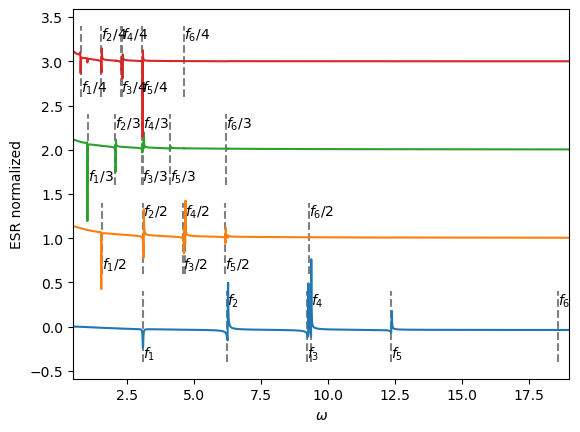

In [60]:
shift = 1


plt.vlines(resonant  , -.4+0*shift, .4+0*shift, 'gray', '--')
plt.vlines(resonant/2, -.4+1*shift, .4+1*shift, 'gray', '--')
plt.vlines(resonant/3, -.4+2*shift, .4+2*shift, 'gray', '--')
plt.vlines(resonant/4, -.4+3*shift, .4+3*shift, 'gray', '--')

plt.plot(frequencies, I1n+0*shift)
plt.plot(frequencies, I2n+1*shift)
plt.plot(frequencies, I3n+2*shift)
plt.plot(frequencies, I4n+3*shift)

plt.text(resonant[0],0*shift-.2,r'$f_1$', ha='left', va='top')
plt.text(resonant[1],0*shift+.2,r'$f_2$', ha='left', va='bottom')
plt.text(resonant[2],0*shift-.2,r'$f_3$', ha='left', va='top')
plt.text(resonant[3],0*shift+.2,r'$f_4$', ha='left', va='bottom')
plt.text(resonant[4],0*shift-.2,r'$f_5$', ha='left', va='top')
plt.text(resonant[5],0*shift+.2,r'$f_6$', ha='left', va='bottom')

plt.text(resonant[0]/2,1*shift-.2,r'$f_1/2$', ha='left', va='top')
plt.text(resonant[1]/2,1*shift+.2,r'$f_2/2$', ha='left', va='bottom')
plt.text(resonant[2]/2,1*shift-.2,r'$f_3/2$', ha='left', va='top')
plt.text(resonant[3]/2,1*shift+.2,r'$f_4/2$', ha='left', va='bottom')
plt.text(resonant[4]/2,1*shift-.2,r'$f_5/2$', ha='left', va='top')
plt.text(resonant[5]/2,1*shift+.2,r'$f_6/2$',ha='left', va='bottom')

plt.text(resonant[0]/3,2*shift-.2,r'$f_1/3$', ha='left', va='top')
plt.text(resonant[1]/3,2*shift+.2,r'$f_2/3$', ha='left', va='bottom')
plt.text(resonant[2]/3,2*shift-.2,r'$f_3/3$', ha='left', va='top')
plt.text(resonant[3]/3,2*shift+.2,r'$f_4/3$', ha='left', va='bottom')
plt.text(resonant[4]/3,2*shift-.2,r'$f_5/3$', ha='left', va='top')
plt.text(resonant[5]/3,2*shift+.2,r'$f_6/3$', ha='left', va='bottom')

plt.text(resonant[0]/4,3*shift-.2,r'$f_1/4$', ha='left', va='top')
plt.text(resonant[1]/4,3*shift+.2,r'$f_2/4$', ha='left', va='bottom')
plt.text(resonant[2]/4,3*shift-.2,r'$f_3/4$', ha='left', va='top')
plt.text(resonant[3]/4,3*shift+.2,r'$f_4/4$', ha='left', va='bottom')
plt.text(resonant[4]/4,3*shift-.2,r'$f_5/4$', ha='left', va='top')
plt.text(resonant[5]/4,3*shift+.2,r'$f_6/4$', ha='left', va='bottom')

plt.xlim(0.5,19)

plt.xlabel(r'$\omega$')
plt.ylabel(r'ESR normalized')

In [68]:
print(dot.print_lamb())

0	6	0	0.98709 + i0.00000
0	6	1	-0.16018 + i0.00000
1	6	0	-0.12830 + i0.00000
1	6	1	-0.79060 + i0.00000
1	7	0	0.59102 + i0.00000
1	7	1	-0.09591 + i0.00000
2	6	0	0.09591 + i0.00000
2	6	1	0.59102 + i0.00000
2	7	0	0.79060 + i0.00000
2	7	1	-0.12830 + i0.00000
3	7	0	-0.16018 + i0.00000
3	7	1	-0.98709 + i0.00000
4	0	0	-0.16018 + i0.00000
4	0	1	0.98709 + i0.00000
4	1	0	-0.79060 + i0.00000
4	1	1	-0.12830 + i0.00000
4	2	0	0.59102 + i0.00000
4	2	1	0.09591 + i0.00000
5	1	0	-0.09591 + i0.00000
5	1	1	0.59102 + i0.00000
5	2	0	-0.12830 + i0.00000
5	2	1	0.79060 + i0.00000
5	3	0	-0.98709 + i0.00000
5	3	1	-0.16018 + i0.00000

